In [1]:
from src import *

In [2]:
def log_target0(x):
    return -0.5 * x**2
def log_target1(x, D=4):
    return -0.5 * (x - D)**2
def log_target_path(x, path):
    return (1-path) * log_target0(x) + path * log_target1(x)
def grad_log_target_path(x):
    return log_target1(x, D=4) - log_target0(x)

- Initialisation of the hyperparameters 

In [3]:
L = 20  # 0, 0.1, ..., 1.0
nrep = 100
sigmaq = 1
lag = 1
lambda_grid = np.arange(0, L + 1) / L # uniform grid of lambda values in [0, 1]

### Tuning of the parameters $k_\lambda$ and $m_\lambda$ over a uniform grid of size $L$

mk tunning: 100%|██████████| 21/21 [00:00<00:00, 48.14it/s]


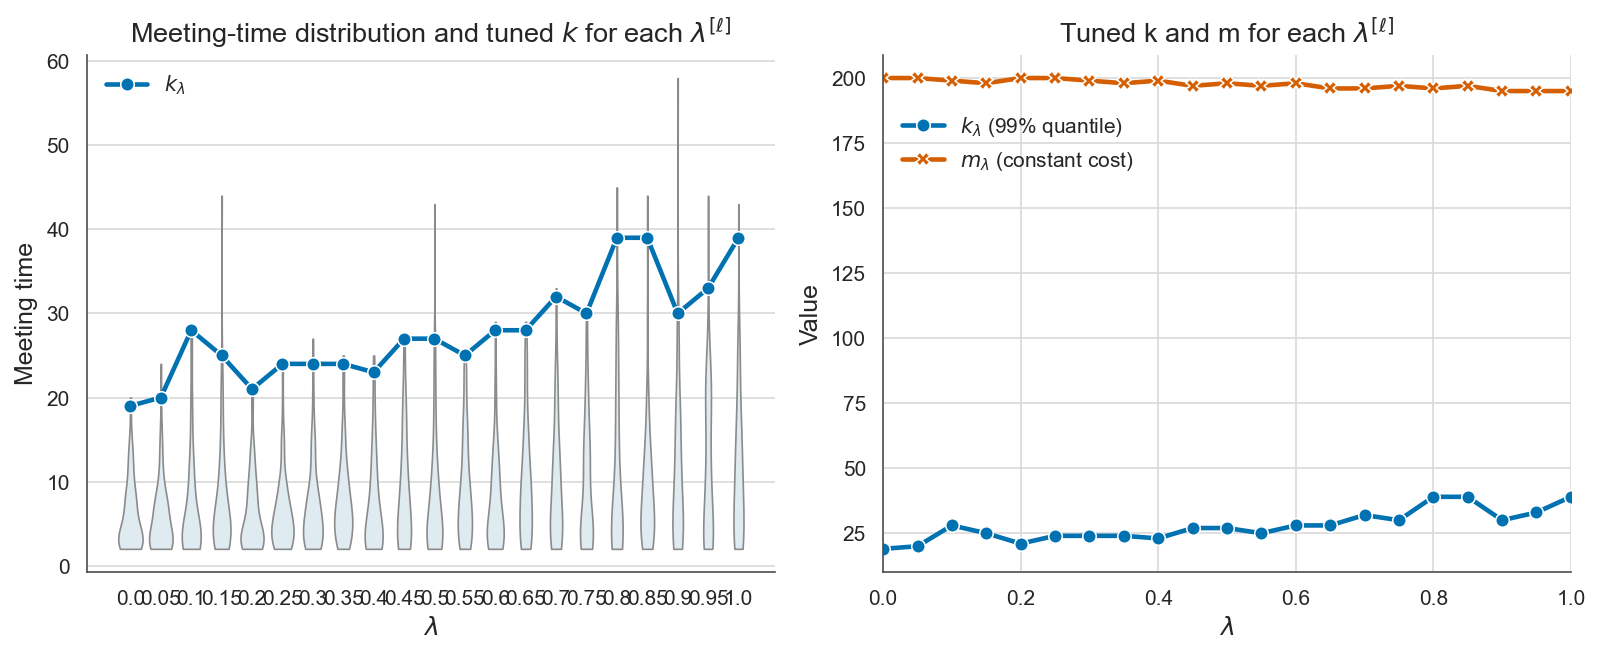

In [4]:
km_grid = tune_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)
plot_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)

### Variance of the UMCMC estimator and the second moment over the grid 
- $\hat{E}(\lambda)$ is the UMCMC of the expectation $\mathbb{E}_{\pi_\lambda}[\nabla_\lambda \log \pi_\lambda]$

Final estimation: 100%|██████████| 21/21 [00:06<00:00,  3.32it/s]


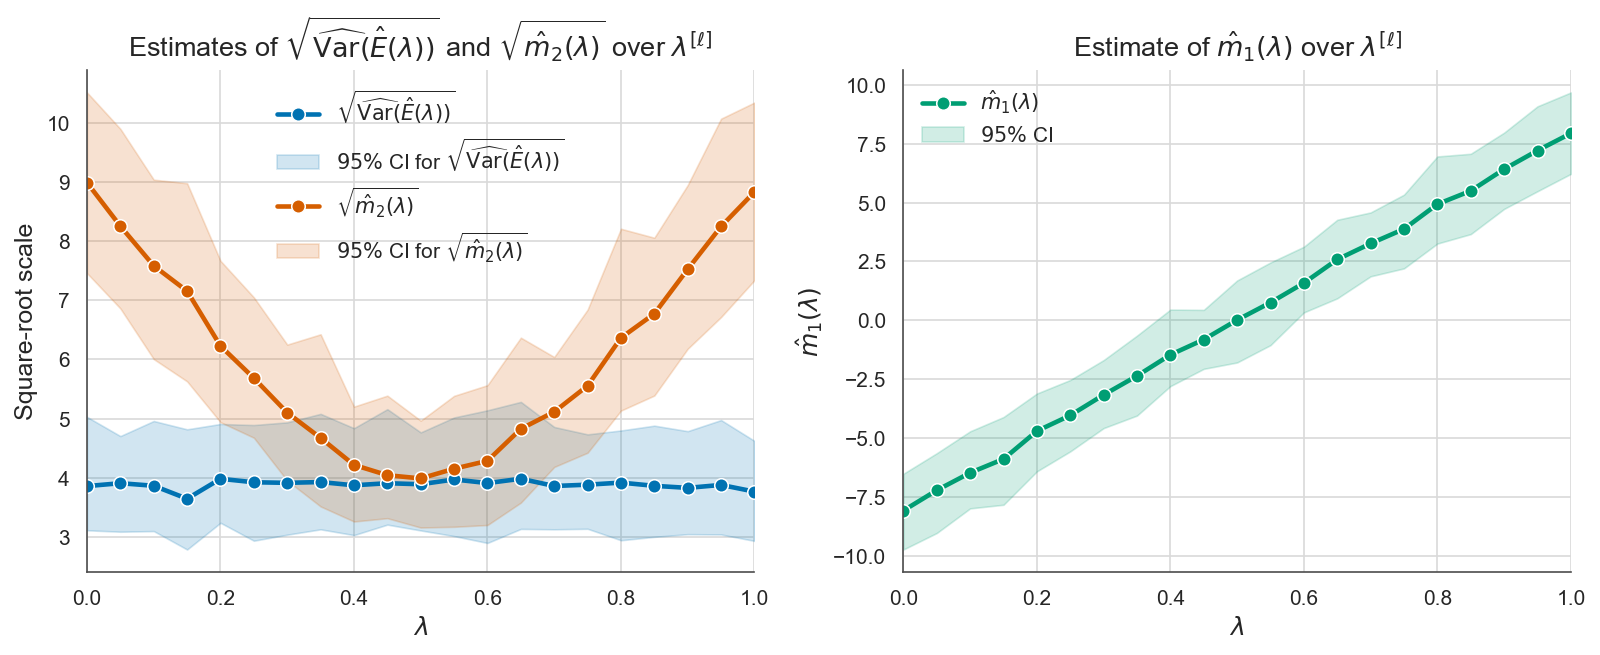

In [5]:
k_grid, m_grid = km_grid["k_grid"], km_grid["m_grid"]
plot_estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)

### Comparaison of IS and Startified based estimator

- Stratified estimator

In [6]:
L = 20

- IS estimator

In [8]:
res = estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)
sqrt_m2 = np.sqrt(res["m2"])

Final estimation: 100%|██████████| 21/21 [00:06<00:00,  3.31it/s]


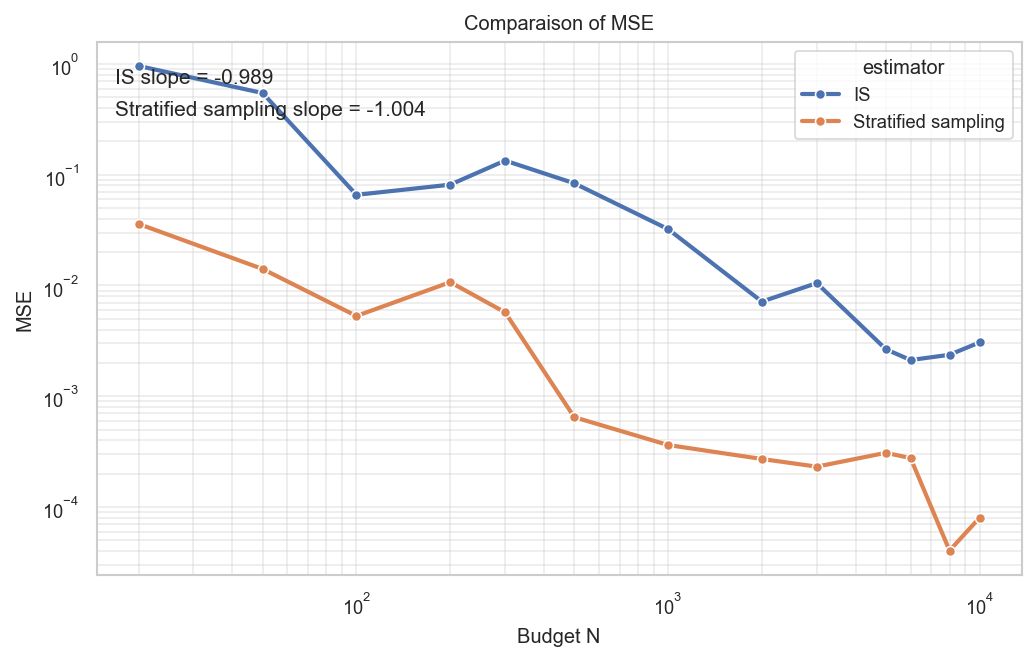

Estimated log-log slopes:
- IS: -0.989
- Stratified sampling: -1.004


In [11]:
M_grid = np.array([20, 50, 100, 200, 300, 500, 1000, 2000, 3000, 5000, 6000, 8000, 10000]) #, 220, 250, 270, 290, 320, 350, 380, 500, 1000]) # 500, 1000, 2000, 3000, 5000
estimator = lambda lam: uestimator_given_lambda(lam, lambda_grid, k_grid, m_grid, sigmaq, lag, log_target_path, grad_log_target_path)

df_mse, slopes = compare_mse_budget_grid_plot(
    L=L,
    M_grid=M_grid,
    estimator=estimator,
    sqrt_m2=sqrt_m2,
    true_value=0,
    nrep=10,
    n_samples_per_bin=10
)

print("Estimated log-log slopes:")
for estimator_name, slope in slopes.items():
    print(f"- {estimator_name}: {slope:.3f}")
